In [1]:
from  ultralytics import YOLO
import torch 
import cv2

In [2]:
print("GPU is available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU is available: False


In [3]:
model = YOLO('yolov8n.pt')

In [5]:
device = "0" if torch.cuda.is_available() else "cpu"
model.train(data="coco128.yaml", epochs=10, imgsz=640, batch=16, device=device)

Ultralytics 8.4.14 🚀 Python-3.12.0 torch-2.2.2 CPU (Intel Core i5-8500 3.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/11 13:29:33 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Ultralytics' does not exist. Creating a new experiment.
2026/02/11 13:29:34 INFO mlflow.bedrock: Enabled auto-tracing for Bedrock. Note that MLflow can only trace boto3 service clients that are created after this call. If you have already created one, please recreate the client by calling `boto3.client`.
2026/02/11 13:29:34 INFO mlflow.trackin

MLflow: logging run_id(aaa11234ad5b47ca8789e9b55fd43e3e) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /Users/imac/Computer_vision/runs/detect/train
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10         0G      1.209      1.373      1.217         76        640: 100% ━━━━━━━━━━━━ 8/8 6.3s/it 50.6s6.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.6s/it 14.6s5.6ss
                   all        128        929      0.668      0.529      0.608      0.449

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10         0G      1.169      1.367      1.229         99        640: 100% ━━━━━━━━━━━━ 8/8 5.6s

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1b2e0d730>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,   

In [6]:
metrics=model.val()
print(metrics)

Ultralytics 8.4.14 🚀 Python-3.12.0 torch-2.2.2 CPU (Intel Core i5-8500 3.00GHz)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 743.5±455.8 MB/s, size: 45.1 KB)
val: Scanning /Users/imac/Computer_vision/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 59.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3s/it 10.5s.4ss
                   all        128        929      0.743      0.614      0.705      0.536
                person         61        254      0.868      0.646      0.781      0.563
               bicycle          3          6      0.939      0.333      0.395       0.33
                   car         12         46      0.718      0.217      0.301      0.191
            motorcycle          4          5      0.723        0.8      0.938      0.731
              airp

In [7]:
results=model.predict(
    source="http://images.cocodataset.org/val2017/000000039769.jpg",
    conf=0.25,
    save=True
)


image 1/1 /Users/imac/Computer_vision/000000039769.jpg: 480x640 2 cats, 1 couch, 2 remotes, 109.1ms
Speed: 2.0ms preprocess, 109.1ms inference, 37.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/imac/Computer_vision/runs/detect/predict


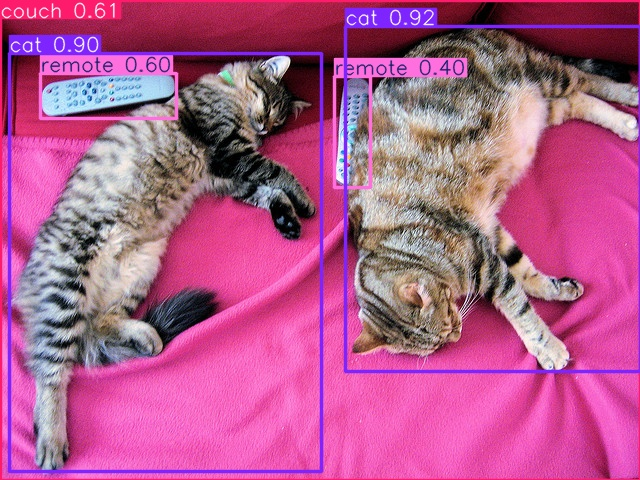

In [8]:
from IPython.display import Image
Image(filename="runs/detect/predict/000000039769.jpg")